Retrieving PhononBSDOSDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Température de Debye ajustée : 1543.10 K
Température d'Einstein ajustée : 1119.81 K


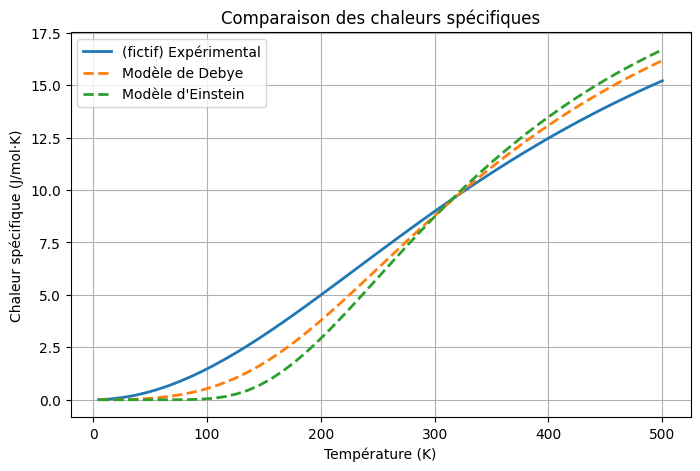

/tmp/ipykernel_2045937/294746032.py:71: RuntimeWarning: divide by zero encountered in divide
  plt.plot(freqs, dos_einstein / dos_einstein.max() * dos_real.max(), '--', label="DoS Einstein", lw=2)
/tmp/ipykernel_2045937/294746032.py:71: RuntimeWarning: invalid value encountered in divide
  plt.plot(freqs, dos_einstein / dos_einstein.max() * dos_real.max(), '--', label="DoS Einstein", lw=2)


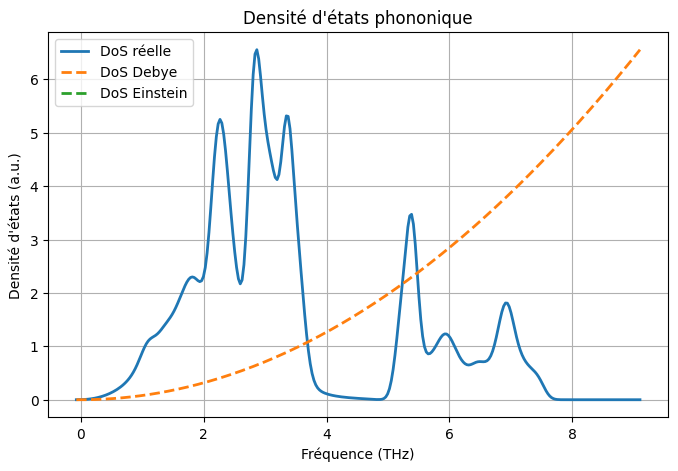

In [19]:
from pymatgen.ext.matproj import MPRester
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k as k_B, hbar
from scipy.optimize import curve_fit


API_KEY = "zA1YwwFoS7C8RQ3ZpVn2lK2ClRoSNTFM"
material_id = "mp-27869 "

mpr = MPRester(API_KEY)
ph_dos = mpr.get_phonon_dos_by_material_id(material_id)

#Fréquences et densité d’états
freqs = np.array(ph_dos.frequencies)
dos_real = np.array(ph_dos.densities)

#données de chaleur spécifique (car pas disponible)
temps = np.linspace(5, 500, 50)
cv_exp = 3 * k_B * 6.022e23 * (temps / 400)**2 / (1 + (temps / 400)**2)

#Température Debye et Einstein
def cv_debye(T, theta_D):
    from scipy.integrate import quad
    def integrand(t): return (t**4 * np.exp(t)) / (np.exp(t) - 1)**2
    x = theta_D / T
    return [9 * k_B * (T_i/theta_D)**3 * quad(integrand, 0, x_i)[0] * 6.022e23 for T_i, x_i in zip(T, x)]

def cv_einstein(T, theta_E):
    x = theta_E / T
    return [3 * k_B * (x_i**2 * np.exp(x_i)) / (np.exp(x_i) - 1)**2 * 6.022e23 for x_i in x]

#Minimise l'erreur
popt_debye, _ = curve_fit(cv_debye, temps, cv_exp, p0=[300])
popt_einstein, _ = curve_fit(cv_einstein, temps, cv_exp, p0=[300])
theta_D, = popt_debye
theta_E, = popt_einstein

#températures ajustées
print(f"Température de Debye ajustée : {theta_D:.2f} K")
print(f"Température d'Einstein ajustée : {theta_E:.2f} K")

#Calculs des chaleurs spécifiques
cv_D = cv_debye(temps, theta_D)
cv_E = cv_einstein(temps, theta_E)

#chaleurs spécifiques
plt.figure(figsize=(8, 5))
plt.plot(temps, cv_exp, label="(fictif) Expérimental", lw=2)
plt.plot(temps, cv_D, '--', label="Modèle de Debye", lw=2)
plt.plot(temps, cv_E, '--', label="Modèle d'Einstein", lw=2)
plt.xlabel("Température (K)")
plt.ylabel("Chaleur spécifique (J/mol·K)")
plt.legend()
plt.grid()
plt.title("Comparaison des chaleurs spécifiques")
plt.show()

#Dos Debye et Einstein
max_freq = freqs.max()
dos_debye = (freqs**2) * (freqs <= max_freq)
omega_E = theta_E * k_B / hbar / (2 * np.pi * 3e10)  # convert to THz
dos_einstein = np.exp(-((freqs - omega_E)**2) / (2 * 0.1**2))

#densités d'états
plt.figure(figsize=(8, 5))
plt.plot(freqs, dos_real, label="DoS réelle", lw=2)
plt.plot(freqs, dos_debye / dos_debye.max() * dos_real.max(), '--', label="DoS Debye", lw=2)
plt.plot(freqs, dos_einstein / dos_einstein.max() * dos_real.max(), '--', label="DoS Einstein", lw=2)
plt.xlabel("Fréquence (THz)")
plt.ylabel("Densité d'états (a.u.)")
plt.legend()
plt.grid()
plt.title("Densité d'états phononique")
plt.show()


